In [1]:
import numpy as np  # Linear algebra
import pandas as pd  # Data processing
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns  # Statistical Data Visualization
import math  # Mathematical operations
import folium  # Interactive map visualization
import plotly.offline as offline  # Interactive visualization
import plotly.graph_objs as go  # Graph objects for Plotly
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ===============================
# 1. Load Dataset
# ===============================
df = pd.read_csv('/kaggle/input/uberdata/final_internship_data.csv')
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [3]:
# ===============================
# 2. Data Cleaning & Preprocessing
# ===============================


In [4]:
# Drop unnecessary categorical columns that may cause issues in numerical processing
columns_to_drop = ["User Name", "Driver Name","User ID","key"]

# Ensure columns exist before dropping them
df = df.drop(columns=columns_to_drop, errors='ignore')

In [5]:
# Handling passenger count: Replace zero passengers with 1
df['passenger_count'] = df['passenger_count'].apply(lambda x: 1 if x == 0 else x)

In [6]:
# Drop rows with missing values in distance metrics
df.dropna(inplace=True)

In [7]:
# Remove extreme fare values
df.drop(df[(df['fare_amount'] > 200) | (df['fare_amount'] < 2.5)].index, inplace=True)

In [8]:
# Outlier detection and removal based on ride distance
df = df[(df['distance'] > 0) & (df['distance'] <= 200)]

In [9]:
# Cap unrealistic airport distances using IQR method
for col in ['jfk_dist', 'ewr_dist', 'lga_dist']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr  # Allow some variation
    df = df[df[col] <= upper_bound]

In [10]:
# ===============================
# 3. Feature Engineering
# ===============================
# Convert pickup_datetime to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [11]:
# Extract time-based features
df['minute'] = df['pickup_datetime'].dt.minute
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear
df['quarter'] = df['pickup_datetime'].dt.quarter
df['time_of_day'] = df['pickup_datetime'].dt.hour.apply(lambda x: 'Night' if x < 6 else ('Morning' if x < 12 else ('Afternoon' if x < 18 else 'Evening')))
df['rush_hour'] = df['pickup_datetime'].dt.hour.apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)
df['weekend'] = df['pickup_datetime'].dt.weekday.apply(lambda x: 1 if x in [5, 6] else 0)

In [12]:
# Drop original datetime columns
df.drop(['pickup_datetime'], axis=1, inplace=True)

In [13]:
# Bin distance into categories
bins = [0, 2, 5, 10, 20, 50, 200]
labels = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']
df['distance_bin'] = pd.cut(df['distance'], bins=bins, labels=labels)

In [14]:
# Compute price per mile
df['price_per_mile'] = df['fare_amount'] / df['distance']

In [15]:
# ===============================
# 4. Encoding Categorical Variables
# ===============================
# Ordinal encoding for ordered categories
ordinal_features = {'Car Condition': ['Bad', 'Average', 'Good', 'Very Good', 'Excellent'],
                    'Traffic Condition': ['Flow Traffic', 'Dense Traffic', 'Congested Traffic'],
                    'distance_bin': ['Very Short', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']}
ordinal_encoder = OrdinalEncoder(categories=[ordinal_features[col] for col in ordinal_features], handle_unknown='use_encoded_value', unknown_value=-1)
df[list(ordinal_features.keys())] = ordinal_encoder.fit_transform(df[list(ordinal_features.keys())])

In [16]:
# One-hot encoding for unordered categorical variables
df = pd.get_dummies(df, columns=['Weather', 'time_of_day'], drop_first=True)

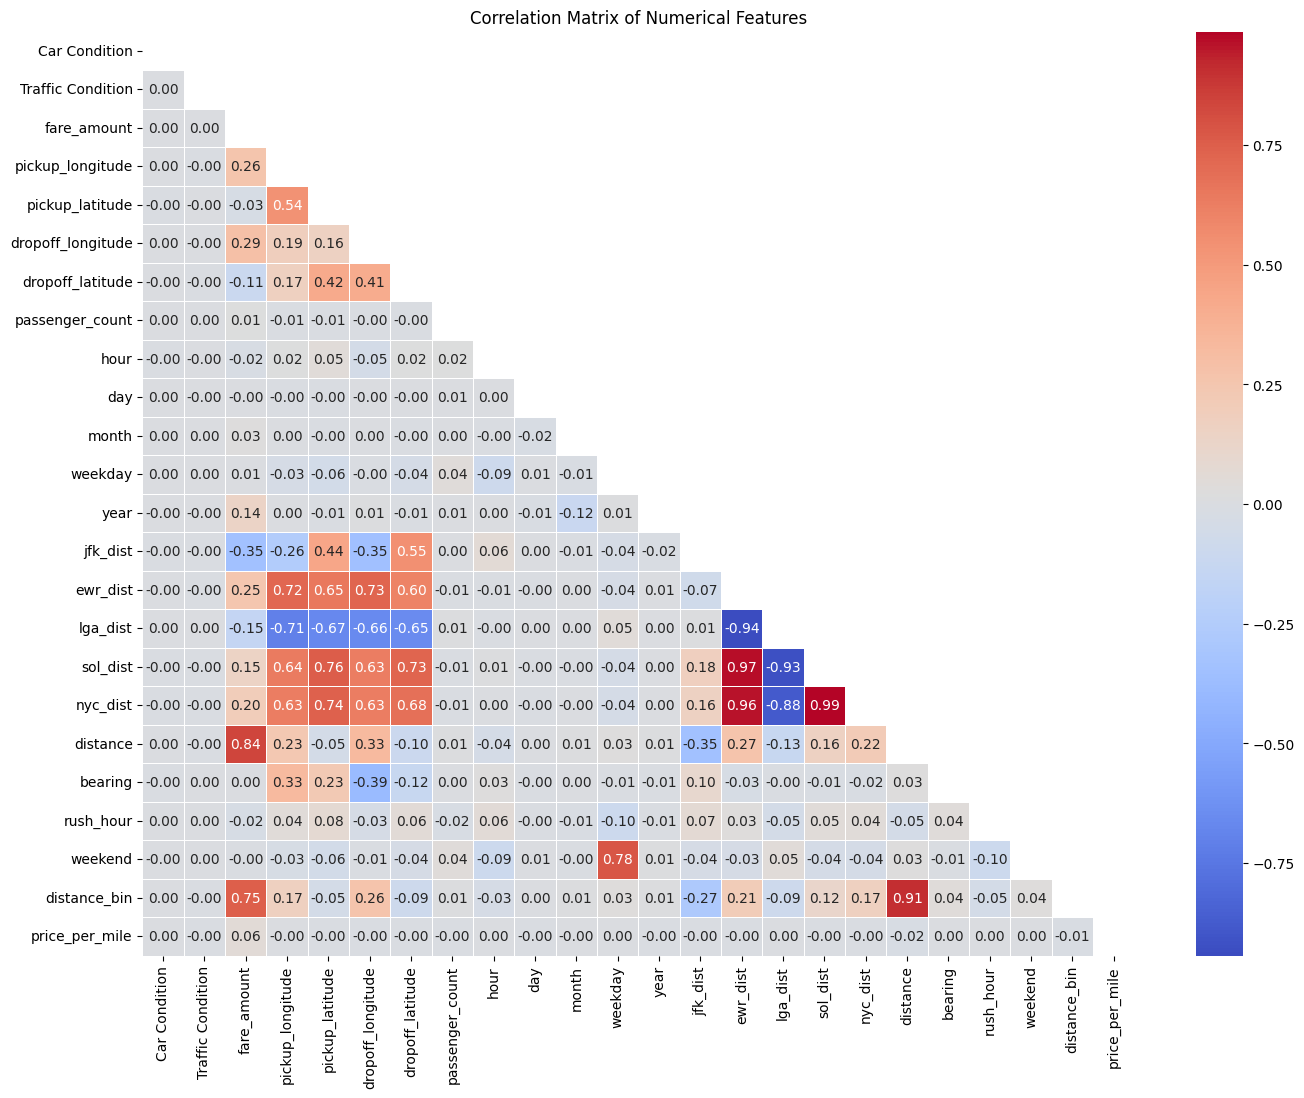

In [17]:
# Correlation matrix for numerical features
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, mask=mask)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [18]:
# Drop invalid location columns
df.drop(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], axis=1, inplace=True)

In [19]:
# Splitting data into features and target
X = df.drop(columns=['fare_amount']) 
y = df['fare_amount']

In [20]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
# Check which columns are non-numeric
non_numeric_columns = X_train.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)

Non-numeric columns: Index([], dtype='object')


In [23]:
for col in non_numeric_columns:
    unseen_values = set(X_test[col]) - set(label_encoders[col].classes_)
    if unseen_values:
        print(f"Unseen values in {col}: {unseen_values}")

In [24]:
for col in non_numeric_columns:
    le = label_encoders[col]
    X_test[col] = X_test[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)


In [25]:
label_encoders = {}
for col in non_numeric_columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

Linear Regression - RMSE: 3.3961, R²: 0.7450


In [28]:
# Ridge Regression
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Ridge Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

Ridge Regression - RMSE: 3.3961, R²: 0.7451


In [35]:
# Lasso Regression
lasso_model = Lasso(alpha=0.0001, max_iter=10000)
lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Lasso Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

Lasso Regression - RMSE: 3.3961, R²: 0.7450


In [36]:
# ElasticNet Regression
elasticnet_model = ElasticNet(alpha=0.0001, l1_ratio=0.5, max_iter=10000)
elasticnet_model.fit(X_train, y_train)
y_pred = elasticnet_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"ElasticNet - RMSE: {rmse:.4f}, R²: {r2:.4f}")

ElasticNet - RMSE: 3.3961, R²: 0.7450


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.275e+03, tolerance: 1.649e+03



In [37]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Random Forest - RMSE: {rmse:.4f}, R²: {r2:.4f}")

Random Forest - RMSE: 0.3547, R²: 0.9972


In [41]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Gradient Boosting - RMSE: {rmse:.4f}, R²: {r2:.4f}")


Gradient Boosting - RMSE: 0.8997, R²: 0.9821


In [42]:
# Find the best model
results = {
    "Linear Regression": r2_score(y_test, linear_model.predict(X_test)),
    "Ridge Regression": r2_score(y_test, ridge_model.predict(X_test)),
    "Lasso Regression": r2_score(y_test, lasso_model.predict(X_test)),
    "ElasticNet": r2_score(y_test, elasticnet_model.predict(X_test)),
    "Random Forest": r2_score(y_test, rf_model.predict(X_test)),
    "Gradient Boosting": r2_score(y_test, gb_model.predict(X_test)),
}

In [43]:
best_model = max(results, key=results.get)
print(f"Best Model: {best_model} with R² = {results[best_model]:.4f}")

Best Model: Random Forest with R² = 0.9972
